In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1/src')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 251 (delta 43), reused 39 (delta 20), pack-reused 159 (from 1)
Receiving objects: 100% (251/251), 6.61 MiB | 19.98 MiB/s, done.
Resolving deltas: 100% (105/105), done.


In [45]:
# local files
import utils
from synthetic_dataset import SyntheticEllipseDataset
from resunet import ResUNet
from bbbc038_dataset import BBBC038Dataset
from center_offset_dataset import CenterOffsetDataset
from plotting import plot_sample, plot_prediction

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cpu'

In [4]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar

if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train
    !rm ./data/stage1_train.zip

if not os.path.exists('./data/stage1_test'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip -P ./data
    !cd data && unzip -q stage1_test.zip -d stage1_test
    !rm ./data/stage1_test.zip

In [5]:
# carrega o dataset

dataset = CenterOffsetDataset(BBBC038Dataset(True, './data/stage1_train'))
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=generator)
test_dataset = BBBC038Dataset(False, './data/stage1_test')

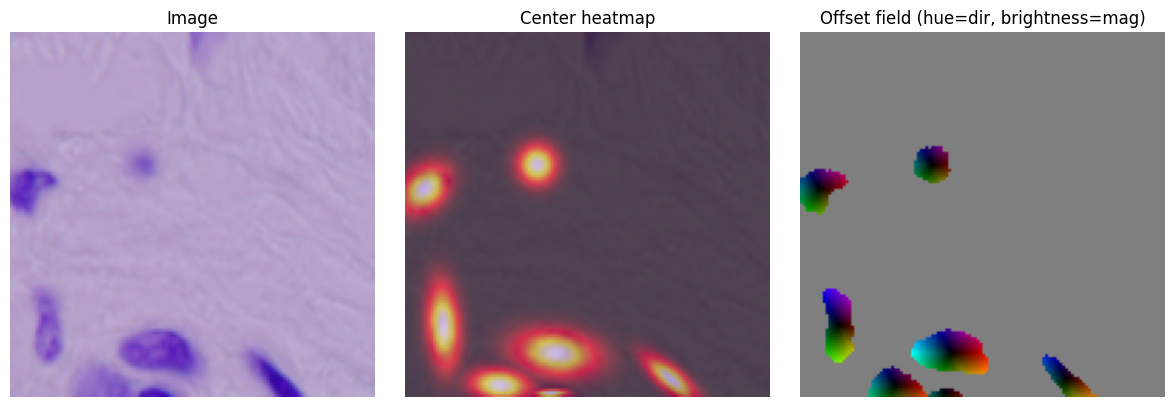

In [6]:
plot_sample(dataset[4])
plt.show()

In [7]:
# cria o modelo

model = ResUNet(3, 3).to(device)
model.load_state_dict(torch.load('instance_weights', map_location=device, weights_only=True))
model.eval()
None

In [8]:
SHOULD_TRAIN = False

if SHOULD_TRAIN:
    # treinando o modelo

    loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    heatmap_loss_fn = nn.MSELoss()
    offset_loss_fn = nn.L1Loss(reduction='none')  # 'none' pra poder mascarar pixel a pixel

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    offset_loss_weight = 1  # ajustem esse peso conforme a escala relativa das perdas

    model.train()
    for epoch in range(25):
        for batch, (_, image, heatmap, offsets, offset_mask) in enumerate(loader):
            image = image.to(device)
            heatmap = heatmap.to(device)
            offsets = offsets.to(device)
            offset_mask = offset_mask.to(device)

            pred = model(image)  # espera-se (B, 3, H, W): canal 0 = heatmap, canais 1:3 = offsets
            pred_heatmap = pred[:, 0:1]
            pred_offsets = pred[:, 1:3]

            loss_heatmap = heatmap_loss_fn(pred_heatmap, heatmap)

            # L1 nos offsets, só nos pixels de foreground (offset_mask expandido pros 2 canais)
            raw_offset_loss = offset_loss_fn(pred_offsets, offsets)
            mask_2ch = offset_mask.expand_as(raw_offset_loss)
            loss_offsets = (raw_offset_loss * mask_2ch).sum() / mask_2ch.sum().clamp(min=1.0)

            loss = loss_heatmap + offset_loss_weight * loss_offsets

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f'{epoch}/{batch} - loss={loss.item():.4f} (heatmap={loss_heatmap.item():.4f}, offsets={loss_offsets.item():.4f})')

In [9]:
@torch.no_grad()
def run_inference(model, sample, device, mask_threshold=0.3):
    """
    Run the model on a single sample and return plain numpy arrays ready
    for plotting: (pred_heatmap, pred_dx, pred_dy, pred_mask).
    """
    model.eval()
    _, image, _, _, _ = sample

    image_batch = image.unsqueeze(0).to(device)
    pred = model(image_batch).cpu()[0]  # (3, H, W)

    pred_heatmap = pred[0].numpy()
    pred_dx, pred_dy = pred[1].numpy(), pred[2].numpy()
    pred_mask = (pred_heatmap > mask_threshold).astype(np.float32)

    return pred_heatmap, pred_dx, pred_dy, pred_mask

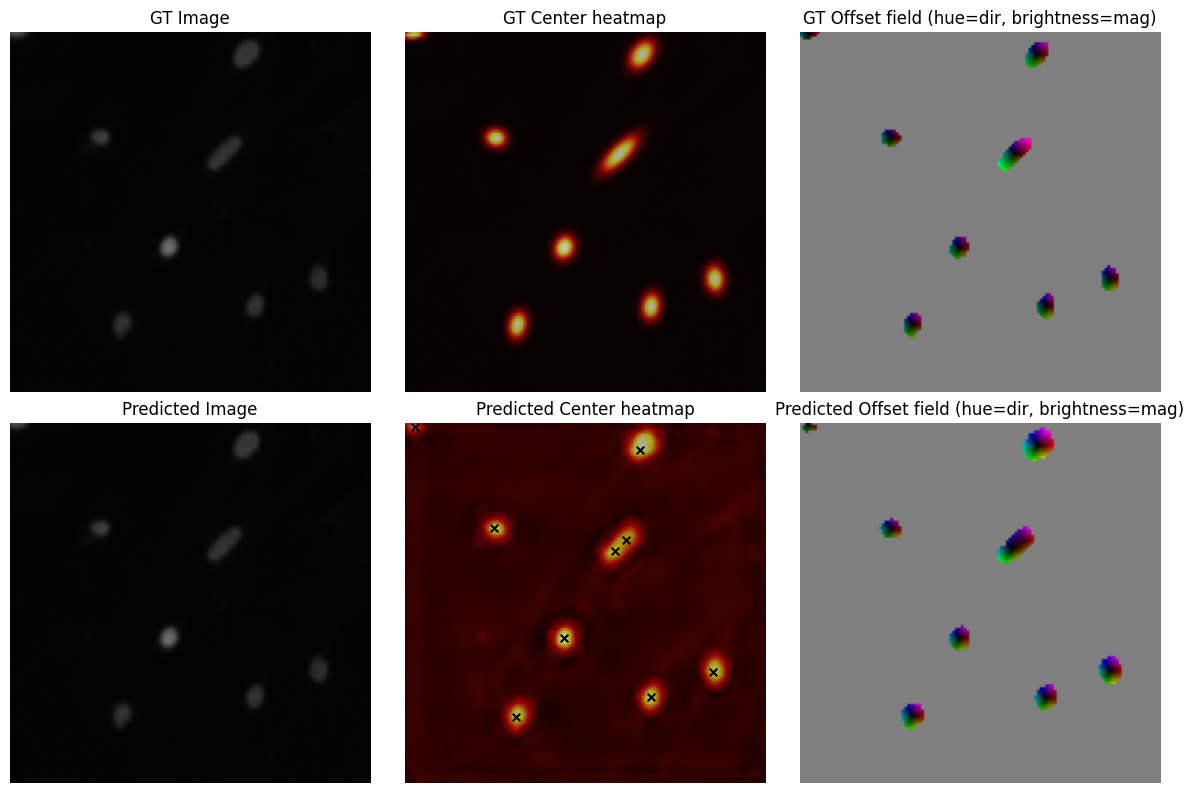

In [41]:
# prediction: inference module computes, viz module only draws
sample = val_dataset[random.randint(0, 50)]
pred_heatmap, pred_dx, pred_dy, pred_mask = run_inference(model, sample, device)
peaks = utils.find_peaks(pred_heatmap)

plot_prediction(sample, pred_heatmap, pred_dx, pred_dy, pred_mask, peaks=peaks)
plt.show()

In [14]:
# salva os pesos do modelo

torch.save(model.state_dict(), 'instance_weights')

In [48]:
@torch.no_grad()
def evaluate_model(model, subset, threshold, nms_kernel, device, batch_size=32, num_workers=4):
    model.eval()

    gt_pred_pairs = []

    positions_base = torch.stack(torch.meshgrid(
        torch.arange(128, dtype=torch.float32),
        torch.arange(128, dtype=torch.float32),
        indexing='ij'
    ))

    center_off_ds = subset.dataset
    base_ds = center_off_ds.base_dataset
    indices = subset.indices

    def collate(batch):
        sample_ids, images, _, instance_maps = zip(*batch)
        return sample_ids, torch.stack(images), instance_maps

    loader = DataLoader(
        Subset(base_ds, indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate,
    )

    for sample_ids, images, instance_maps in tqdm(loader, desc=f"Eval T:{threshold} K:{nms_kernel}", leave=False):
        images = images.to(device)
        preds = model(images).cpu()  # (B, C, H, W)

        for i in range(preds.shape[0]):
            pred = preds[i]
            pred_heatmap = pred[0].numpy()
            pred_offsets = pred[1:3]

            xs, ys = utils.find_peaks(pred_heatmap, threshold=threshold, nms_kernel=nms_kernel)
            if len(xs) == 0:
                pred_instances = np.zeros((128, 128), dtype=np.int64)
            else:
                centroids = np.stack([ys, xs], axis=1)
                bg_mask = pred[0] < threshold

                positions_sample = positions_base.clone()
                positions_sample[0] += pred_offsets[1]
                positions_sample[1] += pred_offsets[0]

                instances_t = utils.assign_instances(positions_sample, centroids, background_mask=bg_mask)
                pred_instances = instances_t.numpy()

            gt_pred_pairs.append((instance_maps[i].numpy(), pred_instances))

    results = utils.compute_map(gt_pred_pairs)
    return results['final_map']

In [49]:
val_map = evaluate_model(model, val_dataset, threshold=0.3, nms_kernel=7, device=device)
print(f"Validation mAP (T=0.3, K=7): {val_map:.4f}")

Validation mAP (T=0.3, K=7): 0.2709


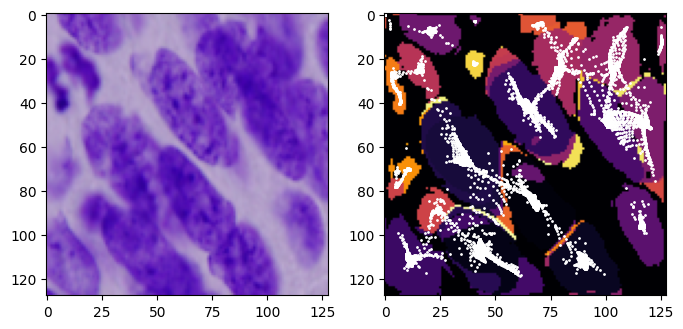

In [51]:
model.eval()
sample_id, image, heatmap, offsets, offset_mask = val_dataset[random.randint(0, 50)]
image_batch = image.unsqueeze(0).to(device)
pred = model(image_batch).cpu()[0].detach()
xs, ys = utils.find_peaks(pred[0].numpy(), threshold=0.3, nms_kernel=5, top_k=50)

centroids = np.stack([ys, xs], axis=1) # (N, 2) as (row, col) to match positions

bg_mask = pred[0] < 0.3  # same threshold you used to zero out positions
positions = torch.stack(torch.meshgrid(
    torch.arange(128, dtype=torch.float32),
    torch.arange(128, dtype=torch.float32),
    indexing='ij'
))
positions[0] += pred[2]
positions[1] += pred[1]
instances = utils.assign_instances(positions, centroids, background_mask=bg_mask)
positions[:,pred[0] < .3] = 0

tx = positions[0].flatten().numpy()
ty = positions[1].flatten().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image.permute(1, 2, 0))
axes[1].imshow(instances, cmap='inferno')
axes[1].scatter(ty, tx, s=1, c='white')
plt.show()